# Ethiopia Climate EDA
## 10 Academy KAIM9 - Week 0

In [1]:
# ============================================
# ETHIOPIA EDA - COMPLETE SETUP
# ============================================

# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.3f' % x)
plt.style.use('seaborn-v0_8')

# Load & Parse Data
df = pd.read_csv('../data/ethiopia.csv')
df['Country'] = 'Ethiopia'
df.replace(-999, np.nan, inplace=True)
df['Date'] = pd.to_datetime(df['YEAR'] * 1000 + df['DOY'], format='%Y%j')
df['Month'] = df['Date'].dt.month

# Drop duplicates
df.drop_duplicates(inplace=True)

print("Libraries imported!")
print("Data loaded!")
print(f"Shape: {df.shape}")
print(f"Date range: {df['Date'].min()} to {df['Date'].max()}")

Libraries imported!
Data loaded!
Shape: (4108, 15)
Date range: 2015-01-01 00:00:00 to 2026-03-31 00:00:00


In [2]:
# Load & Parse Data
df = pd.read_csv('../data/ethiopia.csv')

# Add country column
df['Country'] = 'Ethiopia'

# Replace NASA sentinel values (-999) with NaN
df.replace(-999, np.nan, inplace=True)

# Convert YEAR and DOY to proper datetime
df['Date'] = pd.to_datetime(df['YEAR'] * 1000 + df['DOY'], format='%Y%j')

# Extract Month
df['Month'] = df['Date'].dt.month

print(f"Data loaded successfully!")
print(f"Shape: {df.shape}")
print(f"Date range: {df['Date'].min()} to {df['Date'].max()}")
df.head()

Data loaded successfully!
Shape: (4108, 15)
Date range: 2015-01-01 00:00:00 to 2026-03-31 00:00:00


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date,Month
0,2015,1,11.730,22.750,3.440,19.310,0.000,41.790,2.730,5.070,77.130,4.000,Ethiopia,2015-01-01,1
1,2015,2,12.300,24.010,4.090,19.920,0.000,33.290,2.390,4.190,77.140,3.350,Ethiopia,2015-01-02,1
2,2015,3,12.490,24.170,3.970,20.200,0.000,33.830,1.770,2.760,77.110,3.430,Ethiopia,2015-01-03,1
3,2015,4,14.080,23.780,6.900,16.880,0.000,38.840,0.870,1.280,77.070,4.600,Ethiopia,2015-01-04,1
4,2015,5,14.060,23.150,7.320,15.830,0.000,47.070,1.340,2.140,77.010,5.580,Ethiopia,2015-01-05,1


In [3]:
# Summary Statistics & Missing Values

# Check duplicates
duplicates = df.duplicated().sum()
print(f"Duplicate rows: {duplicates}")
df.drop_duplicates(inplace=True)

# Summary statistics
print("\n Summary Statistics:")
df.describe()

Duplicate rows: 0

 Summary Statistics:


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Date,Month
count,4108.000,4108.000,4108.000,4108.000,4108.000,4108.000,4108.000,4108.000,4108.000,4108.000,4108.000,4108.000,4108,4108.000
mean,2020.131,180.121,16.069,23.199,10.228,12.972,3.634,68.409,1.980,3.575,77.038,9.698,2020-08-15 12:00:00,6.424
min,2015.000,1.000,10.030,15.650,1.170,3.560,0.000,14.420,0.460,0.790,76.360,2.120,2015-01-01 00:00:00,1.000
25%,2017.000,86.000,14.820,21.110,8.418,9.830,0.020,59.030,1.407,2.720,76.980,8.070,2017-10-23 18:00:00,3.000
50%,2020.000,179.000,16.040,22.740,10.990,13.030,0.820,71.120,1.970,3.530,77.040,10.270,2020-08-15 12:00:00,6.000
75%,2023.000,272.000,17.360,25.170,12.220,16.020,4.580,80.802,2.480,4.370,77.100,11.710,2023-06-08 06:00:00,9.000
max,2026.000,366.000,21.530,30.930,15.680,23.240,82.300,91.930,4.130,7.490,77.370,13.520,2026-03-31 00:00:00,12.000
std,3.249,106.295,1.898,2.751,2.607,3.821,6.289,14.736,0.689,1.124,0.099,2.362,NaN,3.477


In [4]:
# Missing Values Report
missing = df.isna().sum()
missing_pct = (df.isna().sum() / len(df)) * 100

missing_report = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
})

print("Missing Values Report:")
print(missing_report[missing_report['Missing Count'] > 0])

# Flag columns with more than 5% missing
high_missing = missing_report[missing_report['Missing %'] > 5]
if len(high_missing) > 0:
    print(f"\n Columns with >5% missing values:")
    print(high_missing)
else:
    print("\n No columns with >5% missing values!")

Missing Values Report:
Empty DataFrame
Columns: [Missing Count, Missing %]
Index: []

 No columns with >5% missing values!


In [5]:
# Outlier Detection using Z-scores
cols = ['T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR', 'RH2M', 'WS2M', 'WS2M_MAX']

z_scores = np.abs(stats.zscore(df[cols].dropna()))
outlier_mask = pd.DataFrame(z_scores > 3, columns=cols)
outlier_counts = outlier_mask.sum()

print("Outlier counts per column (|Z| > 3):")
for col in cols:
    print(f"  {col}: {outlier_counts[col]} outliers")

print(f"\nTotal outlier rows: {outlier_mask.any(axis=1).sum()}")

Outlier counts per column (|Z| > 3):
  T2M: 3 outliers
  T2M_MAX: 0 outliers
  T2M_MIN: 18 outliers
  PRECTOTCORR: 95 outliers
  RH2M: 13 outliers
  WS2M: 3 outliers
  WS2M_MAX: 5 outliers

Total outlier rows: 132


In [6]:
# ============================================
# OUTLIER HANDLING DECISION
# ============================================
# After computing Z-scores, 132 outlier rows were found:
# - PRECTOTCORR: 95 outliers (heavy rainfall = real extreme events)
# - T2M_MIN: 18 outliers (extreme cold nights = climatically meaningful)
# - Other variables: very few outliers (0-13)
#
# DECISION: RETAIN all outliers because:
# 1. Climate extremes ARE the signal we need for COP32 analysis
# 2. Removing them would hide evidence of heatwaves and floods
# 3. They represent real meteorological events, not instrument errors
# ============================================
print("Outlier decision documented!")

Outlier decision documented!


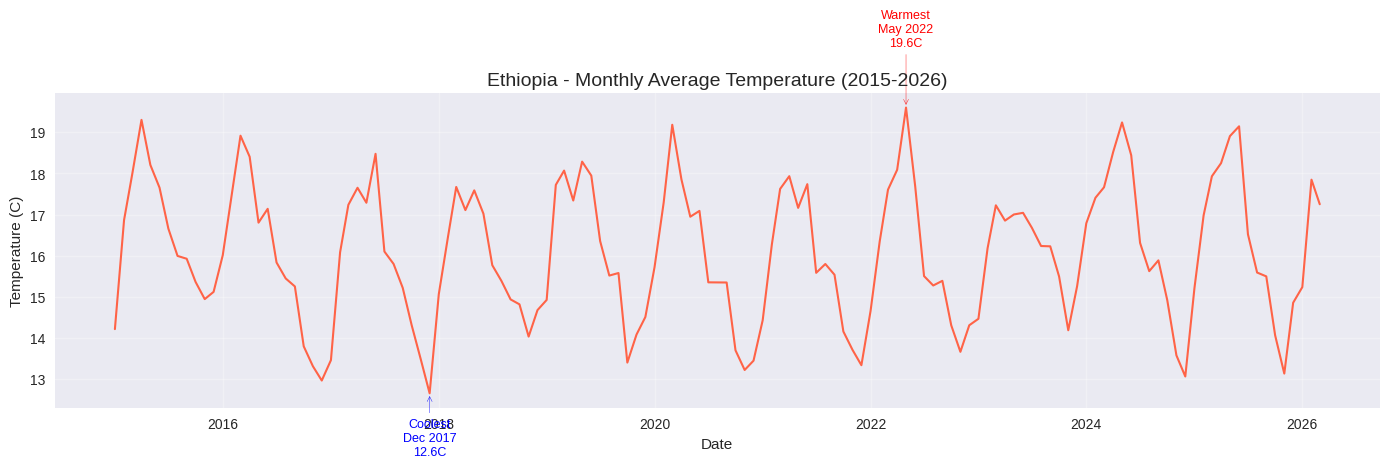

Temperature time series plotted!


In [7]:
# Time Series: Monthly Average Temperature
monthly_temp = df.groupby(df['Date'].dt.to_period('M'))['T2M'].mean()
monthly_temp.index = monthly_temp.index.to_timestamp()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(monthly_temp.index, monthly_temp.values, color='tomato', linewidth=1.5)

# Annotate warmest and coolest months
warmest = monthly_temp.idxmax()
coolest = monthly_temp.idxmin()

ax.annotate(f'Warmest\n{warmest.strftime("%b %Y")}\n{monthly_temp.max():.1f}C',
            xy=(warmest, monthly_temp.max()),
            xytext=(warmest, monthly_temp.max() + 1.5),
            arrowprops=dict(arrowstyle='->', color='red'),
            fontsize=9, color='red', ha='center')

ax.annotate(f'Coolest\n{coolest.strftime("%b %Y")}\n{monthly_temp.min():.1f}C',
            xy=(coolest, monthly_temp.min()),
            xytext=(coolest, monthly_temp.min() - 1.5),
            arrowprops=dict(arrowstyle='->', color='blue'),
            fontsize=9, color='blue', ha='center')

ax.set_title('Ethiopia - Monthly Average Temperature (2015-2026)', fontsize=14)
ax.set_xlabel('Date')
ax.set_ylabel('Temperature (C)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../notebooks/ethiopia_temp_timeseries.png', dpi=150)
plt.show()
print("Temperature time series plotted!")

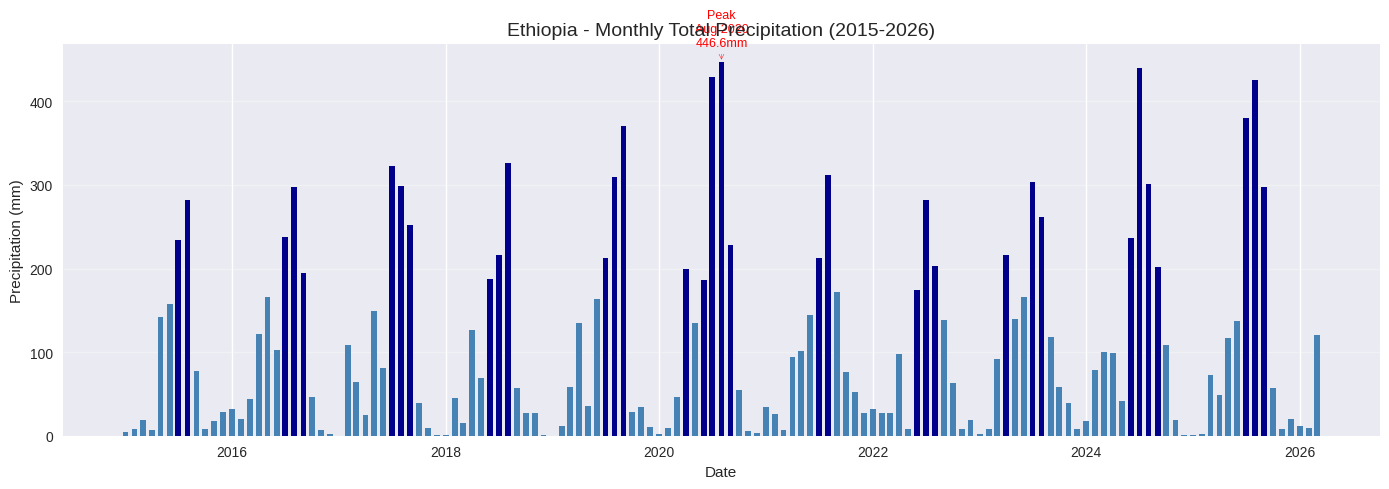

Precipitation bar chart plotted!


In [8]:
# Monthly Total Precipitation Bar Chart
monthly_precip = df.groupby(df['Date'].dt.to_period('M'))['PRECTOTCORR'].sum()
monthly_precip.index = monthly_precip.index.to_timestamp()

fig, ax = plt.subplots(figsize=(14, 5))
colors = ['steelblue' if v < monthly_precip.quantile(0.75) else 'darkblue' 
          for v in monthly_precip.values]
ax.bar(monthly_precip.index, monthly_precip.values, color=colors, width=20)

# Annotate peak months
peak = monthly_precip.idxmax()
ax.annotate(f'Peak\n{peak.strftime("%b %Y")}\n{monthly_precip.max():.1f}mm',
            xy=(peak, monthly_precip.max()),
            xytext=(peak, monthly_precip.max() + 20),
            arrowprops=dict(arrowstyle='->', color='red'),
            fontsize=9, color='red', ha='center')

ax.set_title('Ethiopia - Monthly Total Precipitation (2015-2026)', fontsize=14)
ax.set_xlabel('Date')
ax.set_ylabel('Precipitation (mm)')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('../notebooks/ethiopia_precip_barchart.png', dpi=150)
plt.show()
print("Precipitation bar chart plotted!")

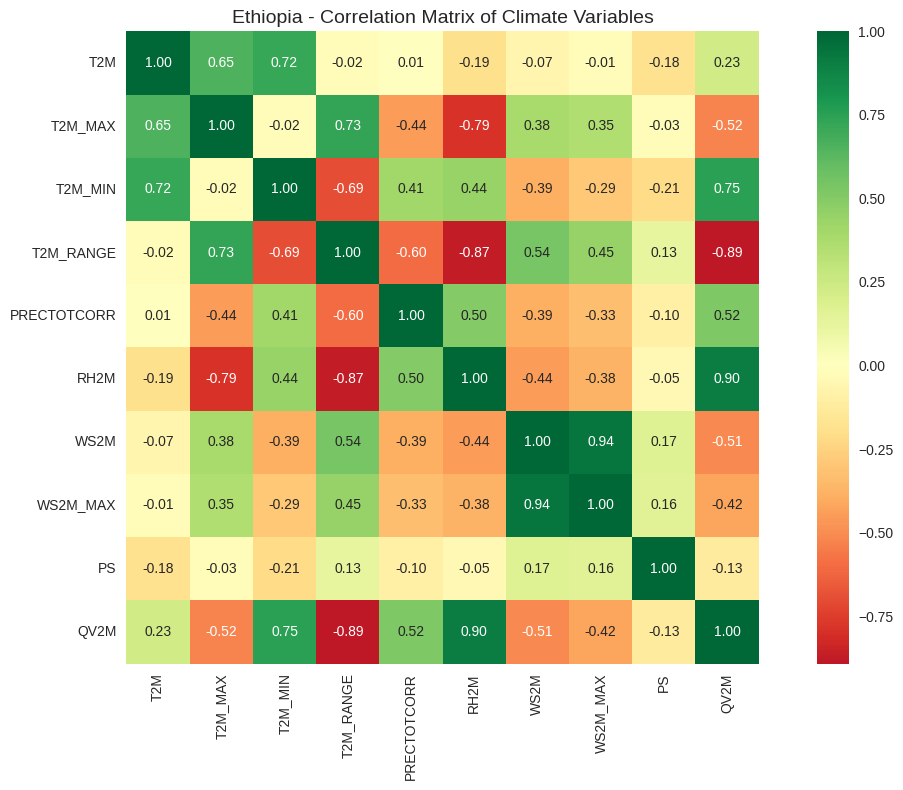

Correlation heatmap plotted!


In [9]:
# Correlation Heatmap
cols = ['T2M', 'T2M_MAX', 'T2M_MIN', 'T2M_RANGE', 
        'PRECTOTCORR', 'RH2M', 'WS2M', 'WS2M_MAX', 'PS', 'QV2M']

fig, ax = plt.subplots(figsize=(12, 8))
corr_matrix = df[cols].corr()

sns.heatmap(corr_matrix, 
            annot=True, 
            fmt='.2f', 
            cmap='RdYlGn',
            center=0,
            square=True,
            ax=ax)

ax.set_title('Ethiopia - Correlation Matrix of Climate Variables', fontsize=14)
plt.tight_layout()
plt.savefig('../notebooks/ethiopia_correlation_heatmap.png', dpi=150)
plt.show()
print("Correlation heatmap plotted!")

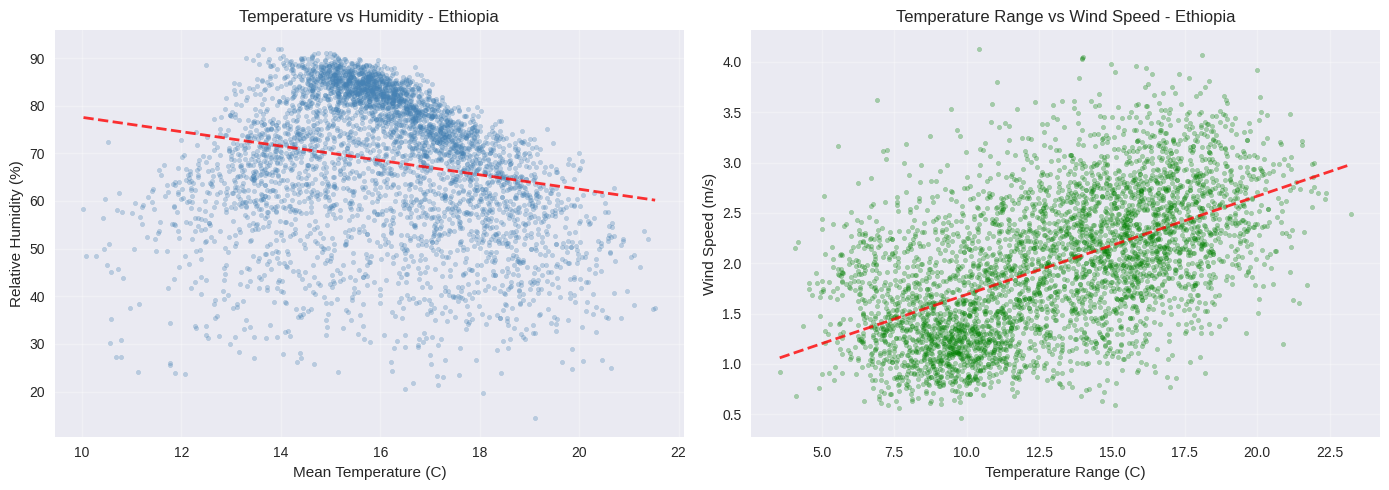

Scatter plots done!


In [10]:
# Scatter Plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: T2M vs RH2M
axes[0].scatter(df['T2M'], df['RH2M'], 
                alpha=0.3, color='steelblue', s=10)
axes[0].set_xlabel('Mean Temperature (C)')
axes[0].set_ylabel('Relative Humidity (%)')
axes[0].set_title('Temperature vs Humidity - Ethiopia')
axes[0].grid(True, alpha=0.3)

# Add trend line
z = np.polyfit(df['T2M'].dropna(), df['RH2M'].dropna(), 1)
p = np.poly1d(z)
axes[0].plot(sorted(df['T2M'].dropna()), 
             p(sorted(df['T2M'].dropna())), 
             "r--", alpha=0.8, linewidth=2)

# Plot 2: T2M_RANGE vs WS2M
axes[1].scatter(df['T2M_RANGE'], df['WS2M'], 
                alpha=0.3, color='green', s=10)
axes[1].set_xlabel('Temperature Range (C)')
axes[1].set_ylabel('Wind Speed (m/s)')
axes[1].set_title('Temperature Range vs Wind Speed - Ethiopia')
axes[1].grid(True, alpha=0.3)

# Add trend line
z2 = np.polyfit(df['T2M_RANGE'].dropna(), df['WS2M'].dropna(), 1)
p2 = np.poly1d(z2)
axes[1].plot(sorted(df['T2M_RANGE'].dropna()), 
             p2(sorted(df['T2M_RANGE'].dropna())), 
             "r--", alpha=0.8, linewidth=2)

plt.tight_layout()
plt.savefig('../notebooks/ethiopia_scatter_plots.png', dpi=150)
plt.show()
print("Scatter plots done!")

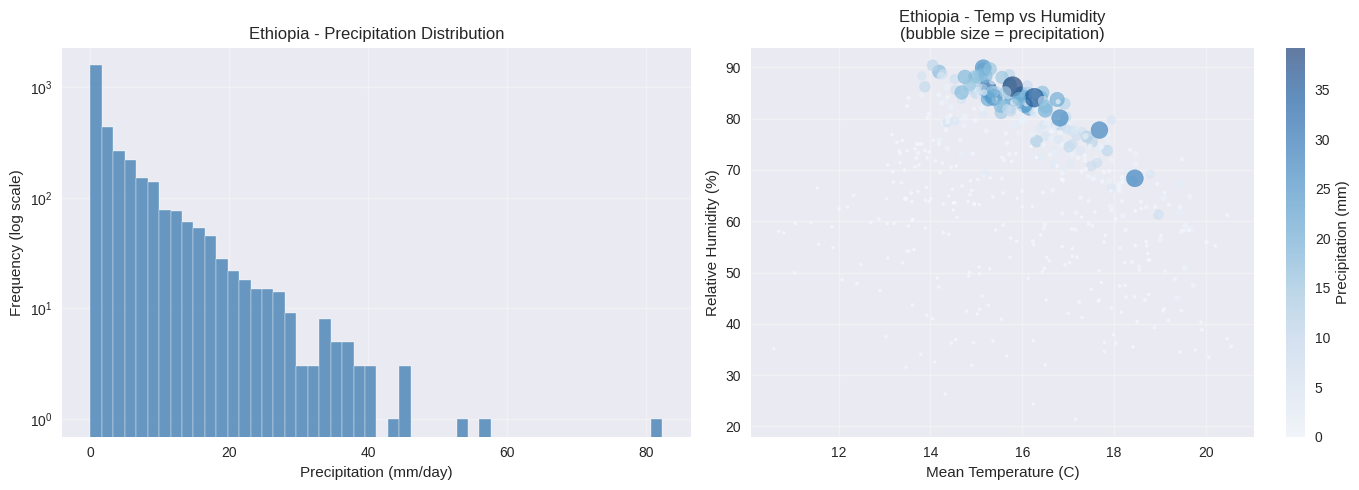

Distribution analysis done!


In [11]:
# Distribution Analysis
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Histogram of PRECTOTCORR (log scale)
precip_nonzero = df['PRECTOTCORR'][df['PRECTOTCORR'] > 0]
axes[0].hist(precip_nonzero, bins=50, color='steelblue', 
             edgecolor='white', alpha=0.8)
axes[0].set_yscale('log')
axes[0].set_xlabel('Precipitation (mm/day)')
axes[0].set_ylabel('Frequency (log scale)')
axes[0].set_title('Ethiopia - Precipitation Distribution')
axes[0].grid(True, alpha=0.3)

# Plot 2: Bubble Chart T2M vs RH2M, size=PRECTOTCORR
sample = df.sample(500, random_state=42)
bubble_size = (sample['PRECTOTCORR'] + 1) * 5
scatter = axes[1].scatter(sample['T2M'], sample['RH2M'],
                          s=bubble_size,
                          c=sample['PRECTOTCORR'],
                          cmap='Blues',
                          alpha=0.6)
plt.colorbar(scatter, ax=axes[1], label='Precipitation (mm)')
axes[1].set_xlabel('Mean Temperature (C)')
axes[1].set_ylabel('Relative Humidity (%)')
axes[1].set_title('Ethiopia - Temp vs Humidity\n(bubble size = precipitation)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../notebooks/ethiopia_distribution.png', dpi=150)
plt.show()
print("Distribution analysis done!")

In [12]:
# Export cleaned data
import os
os.makedirs('../data', exist_ok=True)
df.to_csv('../data/ethiopia_clean.csv', index=False)
print("Cleaned data exported to data/ethiopia_clean.csv")
print(f"Final shape: {df.shape}")

Cleaned data exported to data/ethiopia_clean.csv
Final shape: (4108, 15)
